## Just checking 

In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix
from tqdm import tqdm


In [2]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent.shape)
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)



Shape of combined_cell_types (25932,)
st_ad envi_latent shape: (18516, 512)
sc_ad envi_latent shape: (7416, 512)
(25932, 512)


In [5]:
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)

n_components = 100
pca = PCA(n_components=n_components)
envi_pca = pca.fit_transform(combined_envi_latent)
print("Reduced shape:", envi_pca.shape)

Reduced shape: (25932, 100)


In [9]:
envi_sc_pca= pca.fit_transform(envi_latent_sc)
envi_st_pca= pca.fit_transform(envi_latent_st)
print("Shape of envi_sc_pca", envi_sc_pca.shape)
print("Shape of envi_st_pca", envi_st_pca.shape)

Shape of envi_sc_pca (7416, 100)
Shape of envi_st_pca (18516, 100)


In [6]:
envi_pca

array([[ 1.3092114e+00, -1.8265383e+00,  9.8128426e-01, ...,
         1.5890418e-01,  1.6887602e-01, -1.8677205e-02],
       [ 2.5867896e+00,  6.7092091e-01,  1.9475351e-01, ...,
        -9.4499864e-02, -3.3808118e-03, -3.9019445e-01],
       [ 1.1460099e+00, -2.0634592e+00, -2.0101614e+00, ...,
         3.5203978e-02,  1.3413386e-01,  2.1181980e-01],
       ...,
       [ 2.7570145e+00, -2.2024856e+00,  4.3479390e+00, ...,
        -5.5538422e-01,  1.1403196e-01, -2.6608711e-02],
       [-3.4616897e+00,  1.0008522e+00,  9.9817693e-02, ...,
        -5.4806387e-01,  4.5644993e-01,  3.5773903e-01],
       [-2.8251760e+00,  8.2778352e-01,  1.1101004e+00, ...,
         5.5567253e-01,  4.3190891e-01,  3.3553085e-01]], dtype=float32)

In [7]:
adata=ad.AnnData(X=envi_pca)
adata.obs["cell_type"] = combined_cell_types
adata.obsm["combined_matrix"] = envi_pca
print(adata)

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    obsm: 'combined_matrix'


         Falling back to preprocessing with `sc.pp.pca` and default params.


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


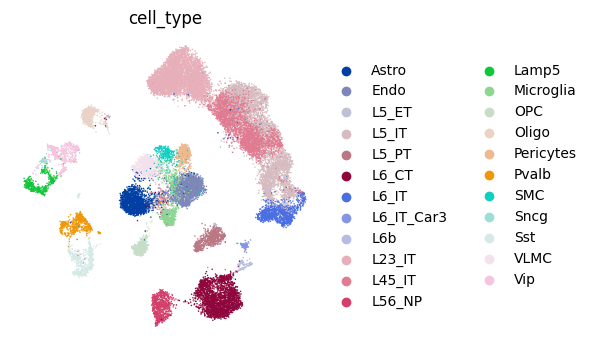

In [8]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], frameon=False)

In [11]:
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

def compute_knn_indices(data, n_neighbors):
    """
    Computes k-nearest neighbors for each point in the dataset.

    :param data: (array) Data matrix of shape (n_samples, n_features)
    :param n_neighbors: (int) Number of nearest neighbors
    :return: (tuple) knn_indices (n_samples, k), knn_distances (n_samples, k), fitted NearestNeighbors object
    """
    n_samples = data.shape[0]
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(data)
    knn_indices = np.zeros((n_samples, n_neighbors), dtype=int)
    knn_distances = np.zeros((n_samples, n_neighbors), dtype=float)

    for i in tqdm(range(n_samples), desc="Computing kNN", ncols=80):
        distances, indices = nbrs.kneighbors(data[i].reshape(1, -1))
        knn_indices[i] = indices[0]
        knn_distances[i] = distances[0]
        
    return knn_indices, knn_distances, nbrs

In [12]:
knn_indices_sc, knn_distances_sc, nbrs_sc = compute_knn_indices(envi_sc_pca, n_neighbors=10)
knn_indices_st, knn_distances_st, nbrs_st = compute_knn_indices(envi_st_pca, n_neighbors=10)

Computing kNN: 100%|█████████████████████| 18516/18516 [01:07<00:00, 274.59it/s]


In [13]:
import numpy as np
from scipy.sparse import csr_matrix
from tqdm import tqdm

def compute_snn_matrix(knn_indices, n_neighbors=10):
    """
    Computes the Shared Nearest Neighbor (SNN) matrix using ranking-based weighting.

    :param knn_indices: (array) Indices of k-nearest neighbors for each point (n_samples, k)
    :param n_neighbors: (int) Number of nearest neighbors considered (default 10)
    :return: (sparse matrix) Weighted SNN graph in CSR format
    """
    n_samples = knn_indices.shape[0]
    snn_matrix = np.zeros((n_samples, n_samples), dtype=np.float32)

    # Precompute neighbor sets and ranking dictionaries
    neighbor_sets = [set(knn_indices[i]) for i in range(n_samples)]
    rankings = [{knn_indices[i][j]: j + 1 for j in range(len(knn_indices[i]))} for i in range(n_samples)]

    for i in tqdm(range(n_samples), desc="Computing SNN Matrix", ncols=80):
        neighbors_i = neighbor_sets[i]

        for j in range(i + 1, n_samples):
            neighbors_j = neighbor_sets[j]
            shared_neighbors = neighbors_i.intersection(neighbors_j)

            if shared_neighbors:
                max_weight = max(
                    n_neighbors - 0.5 * (rankings[i][v] + rankings[j][v])
                    for v in shared_neighbors
                )
                # max_weight = max(0.5 * (rankings[i][v] + rankings[j][v])
                #     for v in shared_neighbors)
                snn_matrix[i, j] = max_weight
                snn_matrix[j, i] = max_weight  # Symmetric assignment

    return csr_matrix(snn_matrix)


In [14]:
snn_matrix_sc = compute_snn_matrix(knn_indices_sc, n_neighbors=10)
snn_matrix_st = compute_snn_matrix(knn_indices_st, n_neighbors=10)
print("Shape of SNN matrix for sc data:", snn_matrix_sc.shape)
print("Shape of SNN matrix for st data:", snn_matrix_st.shape)

Computing SNN Matrix: 100%|██████████████| 18516/18516 [00:42<00:00, 434.24it/s]


Shape of SNN matrix for sc data: (7416, 7416)
Shape of SNN matrix for st data: (18516, 18516)


In [ ]:
#combine both snn matrices row to row and column to column
snn_matrix_combined = csr_matrix((snn_matrix_sc.shape[0] + snn_matrix_st.shape[0], snn_matrix_sc.shape[1] + snn_matrix_st.shape[1]))
print("Shape of combined SNN matrix:", snn_matrix_combined.shape)


Shape of combined SNN matrix: (25932, 25932)



In [20]:
snn_matrix_combined

<25932x25932 sparse matrix of type '<class 'numpy.float64'>'
	with 0 stored elements in Compressed Sparse Row format>

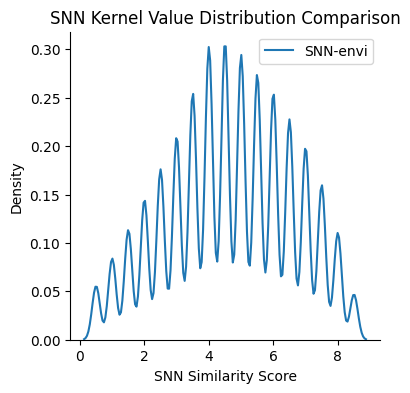

In [21]:
sns.kdeplot(snn_matrix_sc.data, label="SNN-envi")
plt.legend()
plt.title("SNN Kernel Value Distribution Comparison")
plt.xlabel("SNN Similarity Score")
plt.ylabel("Density")
plt.show()

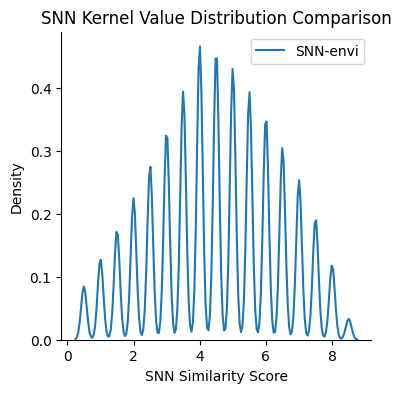

In [22]:
sns.kdeplot(snn_matrix_st.data, label="SNN-envi")
plt.legend()
plt.title("SNN Kernel Value Distribution Comparison")
plt.xlabel("SNN Similarity Score")
plt.ylabel("Density")
plt.show()

In [60]:
import numpy as np
from scipy.sparse import csr_matrix
from tqdm import tqdm

def compute_snn_matrix_avg(knn_indices, knn_distances, n_neighbors=10):
    """
    Computes the Shared Nearest Neighbor (SNN) matrix using average distances
    of shared neighbors instead of rankings.

    :param knn_indices: (array) Indices of k-nearest neighbors for each point (n_samples, k)
    :param knn_distances: (array) Distances to k-nearest neighbors (n_samples, k)
    :param n_neighbors: (int) Number of nearest neighbors considered (default 10)
    :return: (sparse matrix) Weighted SNN graph in CSR format
    """
    n_samples = knn_indices.shape[0]
    snn_matrix = np.zeros((n_samples, n_samples), dtype=np.float32)

    # Build neighbor distance dictionaries
    distance_dicts = [{knn_indices[i][j]: knn_distances[i][j] for j in range(knn_indices.shape[1])}
                      for i in range(n_samples)]

    for i in tqdm(range(n_samples), desc="Computing SNN Matrix", ncols=80):
        neighbors_i = set(knn_indices[i])

        for j in range(i + 1, n_samples):
            neighbors_j = set(knn_indices[j])
            shared_neighbors = neighbors_i.intersection(neighbors_j)

            if shared_neighbors:
                avg_distances = [
                    0.5 * (distance_dicts[i][v] + distance_dicts[j][v])
                    for v in shared_neighbors
                ]
                mean_avg_distance = np.mean(avg_distances)

                
                similarity = 1.0 / (1.0 + mean_avg_distance)  

                snn_matrix[i, j] = similarity
                snn_matrix[j, i] = similarity  

    return csr_matrix(snn_matrix)
snn_matrix_sc_avg = compute_snn_matrix_avg(knn_indices_sc, knn_distances_sc, n_neighbors=10)
snn_matrix_st_avg = compute_snn_matrix_avg(knn_indices_st, knn_distances_st, n_neighbors=10)

Computing SNN Matrix: 100%|███████████████| 18516/18516 [03:07<00:00, 98.97it/s]


In [76]:
#combine snn matrices row to row and column to column   
snn_matrix_combined_avg = csr_matrix((snn_matrix_sc_avg.shape[0] + snn_matrix_st_avg.shape[0], snn_matrix_sc_avg.shape[1] + snn_matrix_st_avg.shape[1]))
print("Shape of combined SNN matrix:", snn_matrix_combined_avg.shape)

Shape of combined SNN matrix: (25932, 25932)


In [64]:
snn_matrix_combined_avg

<25932x25932 sparse matrix of type '<class 'numpy.float64'>'
	with 0 stored elements in Compressed Sparse Row format>

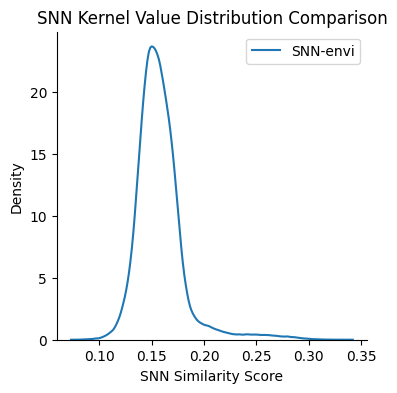

In [74]:
sns.kdeplot(snn_matrix_sc_avg.data, label="SNN-envi")
plt.legend()
plt.title("SNN Kernel Value Distribution Comparison")
plt.xlabel("SNN Similarity Score")
plt.ylabel("Density")
plt.show()

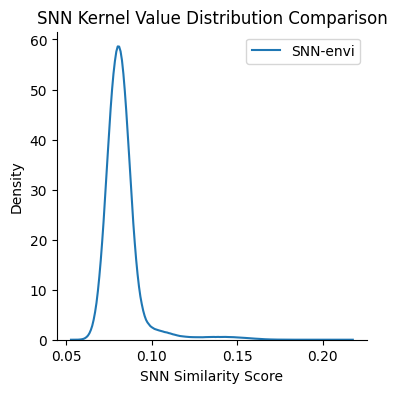

In [75]:
sns.kdeplot(snn_matrix_st_avg.data, label="SNN-envi")
plt.legend()
plt.title("SNN Kernel Value Distribution Comparison")
plt.xlabel("SNN Similarity Score")
plt.ylabel("Density")
plt.show()

In [66]:
import SEACells
#Construct kernel matrix

n_SEACells=100 
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [69]:
adata.obsp["snn_graph"] = snn_matrix_combined_avg

In [70]:
model= SEACells.core.SEACells(adata, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [71]:
adata

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type', 'SEACell'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities', 'snn_graph'

In [72]:
model.construct_kernel_matrix_updated()

using your code
Using the updated snn_kernel to calculate this 
Welcome to normalized SNN kernel!
Converting to CSR format...


In [73]:
M=model.kernel_matrix
print(M)

  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0
  (4, 4)	1.0
  (5, 5)	1.0
  (6, 6)	1.0
  (7, 7)	1.0
  (8, 8)	1.0
  (9, 9)	1.0
  (10, 10)	1.0
  (11, 11)	1.0
  (12, 12)	1.0
  (13, 13)	1.0
  (14, 14)	1.0
  (15, 15)	1.0
  (16, 16)	1.0
  (17, 17)	1.0
  (18, 18)	1.0
  (19, 19)	1.0
  (20, 20)	1.0
  (21, 21)	1.0
  (22, 22)	1.0
  (23, 23)	1.0
  (24, 24)	1.0
  :	:
  (25907, 25907)	1.0
  (25908, 25908)	1.0
  (25909, 25909)	1.0
  (25910, 25910)	1.0
  (25911, 25911)	1.0
  (25912, 25912)	1.0
  (25913, 25913)	1.0
  (25914, 25914)	1.0
  (25915, 25915)	1.0
  (25916, 25916)	1.0
  (25917, 25917)	1.0
  (25918, 25918)	1.0
  (25919, 25919)	1.0
  (25920, 25920)	1.0
  (25921, 25921)	1.0
  (25922, 25922)	1.0
  (25923, 25923)	1.0
  (25924, 25924)	1.0
  (25925, 25925)	1.0
  (25926, 25926)	1.0
  (25927, 25927)	1.0
  (25928, 25928)	1.0
  (25929, 25929)	1.0
  (25930, 25930)	1.0
  (25931, 25931)	1.0


In [54]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 97 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 13/13 [00:00<00:00, 58.71it/s]

Selecting 3 cells from greedy initialization.


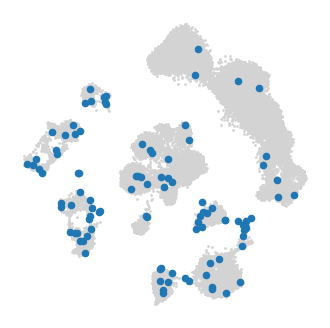

In [56]:
SEACells.plot.plot_initialization(adata, model)

In [57]:
model.fit(min_iter=10, max_iter=50)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
  DEBUG: _updateA norms: kernel_matrix=2.55e+02, P=9.73e+01, PtP=3.48e+01, PtM=9.73e+01
 _updateA iter 1: Grad norm: 2.33e+02
 _updateA iter 2: Grad norm: 9.08e+02
 _updateA iter 3: Grad norm: 8.02e+02
 _updateA iter 4: Grad norm: 5.39e+02
 _updateA iter 5: Grad norm: 4.73e+02
 _updateA iter 6: Grad norm: 3.81e+02
 _updateA iter 7: Grad norm: 3.40e+02
 _updateA iter 8: Grad norm: 3.12e+02
 _updateA iter 9: Grad norm: 2.86e+02
 _updateA iter 10: Grad norm: 2.61e+02
 _updateA iter 11: Grad norm: 2.39e+02
 _updateA iter 12: Grad norm: 2.35e+02
 _updateA iter 13: Grad norm: 2.58e+02
 _updateA iter 14: Grad norm: 2.81e+02
 _updateA iter 15: Grad norm: 2.78e+02
 _updateA iter 16: Grad norm: 2.67e+02
 _updateA iter 17: Grad norm: 2.51e+02
 _updateA iter 18: Grad norm: 2.41e+02
 _updateA iter 19: Grad norm: 2.35e+02
 _updateA iter 20: Grad norm: 2.26e+02
 _updateA iter 21: Grad norm: 2.33e+02
 _updateA iter 22: Grad norm: 2.54e+02
 _updateA iter 23: Grad norm: 2.

KeyboardInterrupt: 

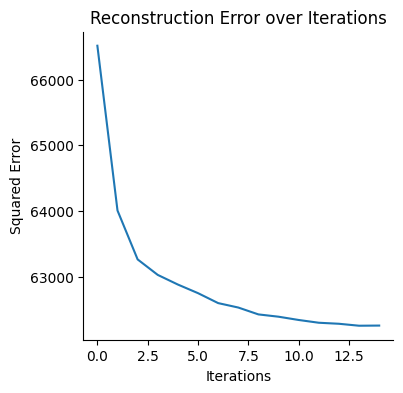

In [58]:
model.plot_convergence()

/Users/anushka/Documents/Undergraduate-Project/SEACells_updated/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


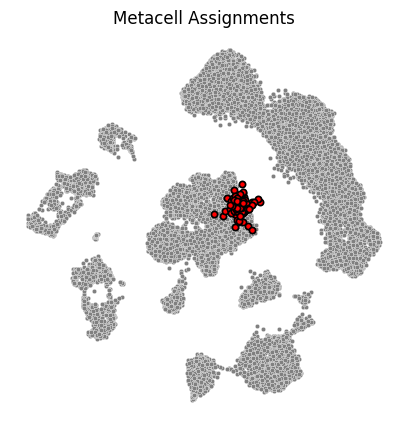

In [59]:
SEACells.plot.plot_2D(adata, colour_metacells=False)